# Wearable Stress and Affect Detection (WESAD) - UCI Machine Learning Repository (ICMI 2018)

Множеството се состои од податоци за 15 личности кои учествувале во експеримент од 5 последователни сесии во контролирана околина кои биле наменети да предизвикаат различни реакции кај учесниците.

---

### Опис

Учесниците се идентификувани како `Sx` (од `S2` до `S17`, каде што податоците за `S1` и `S12` се отстранети поради проблеми со сензорите).

\
Податоците за секој учесник се собрани од два уреди кои ги носеле во исто време:
1. RespiBAN Professional поставен на градите со рата на отчитување од `700 Hz`.
2. Empatica E4 поставен на раката (wrist) со различни рати на отчитување - `BVP: 64 Hz`, `EDA: 4 Hz`.

\
Секој учесник прошол низ 5 сесии во следниот редослед:
1. **Baseline (20 min)** - седење во тишина, гледајќи видео од воз како патува **со цел да се воспостави неутрална физиолошка состојба**.
2. **Amusement (4 min)** - гледање смешно видео **со цел да се предизвика позитивна реакција за контраст со стресот**.
3. **Stress (10 min)** - следејќи го `Trier Social Stress Test (TSST)` учесниците имале интервју за работа пред двајца строги и нереспонзивни интервјуери, а потоа имале задача да бројат наназад од 2043 со скокови од 17 додека биле константно корегирани и брзани **со цел да се предизвика стресна состојба**.
4. **Meditation (5 min)** - слушање на снимка со инструкции за релаксација и медитација **со цел да се воспостави фаза на опоравување/одмор**.
5. **Meditation (5 min)** - слушање на снимка со инструкции за релаксација и медитација **со цел да се воспостави фаза на опоравување/одмор**.

Меѓу секоја сесија, учесниците пополнувале прашалници за самоевалуација на нивната емотивна состојба (PANAS, STAI, DIM). По стресната сесија, учесниците дополнително пополниле SSSQ прашалник за ангажираност во задачата и загриженост.

Секоја од овие сесии е лабелирана во `.pkl` датотеките: `0 = transitional periods (ignore)`, `1 = baseline`, `2 = stress`, `3 = amusement`, `4 = meditation`, `5, 6, 7 = ignore`.

\
Податоците собрани од двата сензори се следните:

| Уред          | Сигнал               |  Рата  |               Единица              |
|---------------|----------------------|:------:|:----------------------------------:|
| RespiBAN Prof | ECG                  | 700 Hz |                 mV                 |
|               | EDA                  | 700 Hz |                 μS                 |
|               | EMG                  | 700 Hz |                 mV                 |
|               | Respiration (PZT)    | 700 Hz |                  %                 |
|               | Temperature          | 700 Hz |                 °C                 |
|               | 3-axis Accelerometer | 700 Hz |                  g                 |
|               |                      |        |                                    |
| Empatica E4   | BVP (PPG)            |  64 Hz | raw (proportional to blood volume) |
|               | EDA                  |  4 Hz  |                 μS                 |
|               | Temperature          |  4 Hz  |                 °C                 |
|               | 3-axis Accelerometer |  32 Hz |                1/64g               |

\
Синхронизацијата на отчитувањата на двата уреди била направена така што учесниците го допреле едниот уред на другиот два пати. Тоа предизвикало "spike" во сигналите од двата уреди кој потоа бил искористен за рачно синхронизирање на сигналите.

\
Информации за прашалниците по секоја сесија:

| Прашалник                             | Кратенка | Опис                                                                                  |
|---------------------------------------|----------|---------------------------------------------------------------------------------------|
| Positive and Negative Affect Schedule | PANAS    | Секое прашање има 20 понудени чувства кои се рангираат од 1 до 5 по секоја сесија.    |
| State-Trait Anxiety Inventory         | STAI     | Секое прашање се одговара со ранг од 1 до 4 за тоа колку анкциозно се осеќа личноста. |
| Dimensional Affect Model              | DIM      | Две мерки со вредности од 1 до 9. Една за удобност и другата за возбуда.              |
| Short Stress State Questionnaire      | SSSQ     | Прашања директно поврзани со ангажираност, паника, и загриженост.                     |

# 
# Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import heartpy as hp
import matplotlib.pyplot as plt
from scipy.signal import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
import warnings
warnings.filterwarnings('ignore')

# 
# Constants & Loading

In [3]:
SUBJECTS = [f'S{i}' for i in range(2, 17 + 1) if i != 12]

ECG_FS = 700  # Electrocardiogram, measuring the electrical signals from a beating heart
BVP_FS = 64   # Blood Volume Pulse, measuring changes in blood flow in the body with each heartbeat

In [4]:
SUBJECTS_DATA = {}
for sub in SUBJECTS:
    print(f'[-] Loading {sub} data...', end = '\r')

    
    # Load subject data
    with open(f'WESAD/{sub}/{sub}.pkl', 'rb') as file:
        data = pickle.load(file, encoding = 'latin1')

    
    # Load subject info
    data['info'] = {
        'Age' : None, 'Height (cm)' : None, 'Weight (kg)' : None, 'Gender' : None, 'Dominant hand' : None, 'Pre-requisites' : [], 'Notes' : []
    }
    
    with open(f'WESAD/{sub}/{sub}_readme.txt', 'r') as file:
        content = file.read()

    for info in list(data['info'])[:5]:
        if info not in content:
            continue
        value = content.split(f'{info}:')[1].split('\n')[0].strip()
        data['info'][info] = int(value) if value.isdigit() else value

    for info in content.split('### Study pre-requisites ###')[1].split('\n'):
        if info.startswith('#'):
            break
        if '?' not in info:
            continue
        data['info']['Pre-requisites'].append(info)

    for info in content.split('### Additional notes ###')[1].split('\n'):
        if not info:
            continue
        data['info']['Notes'].append(info)

    
    # Load session timings
    data['timing'] = {}

    with open(f'WESAD/{sub}/{sub}_quest.csv', 'r') as file:
        lines = file.readlines()

    conditions = lines[1].strip().split(';')[1:]
    s_times = lines[2].strip().split(';')[1:]
    e_times = lines[3].strip().split(';')[1:]

    for i, condition in enumerate(conditions):
        if condition and condition not in ['bRead', 'fRead', 'sRead']:
            s_time = float(s_times[i])
            e_time = float(e_times[i])
            data['timing'][condition] = {'start' : s_time, 'end' : e_time, 'duration' : e_time - s_time}


    # Questionnaire responses
    data['questionnaire'] = {'PANAS' : [], 'STAI' : [], 'DIM' : [], 'SSSQ' : []}
    
    for line in lines:
        line = line.strip()
        if not line.startswith('#'):
            continue
            
        parts = [p.strip() for p in line.lstrip('#').strip().split(';')]
        key = parts[0]
        if key not in data['questionnaire']:
            continue
            
        values = [int(v) for v in parts[1:] if v.isdigit()]
        if not values:
            continue
            
        if key == 'SSSQ':
            data['questionnaire'][key] = values  # single row
        else:
            data['questionnaire'][key].append(values)  # one row per session

    
    # Save subject data
    SUBJECTS_DATA[sub] = data
    print(f'[✔] Loading {sub} data...')

print('Finished loading data for all subjects.')

[✔] Loading S2 data...
[✔] Loading S3 data...
[✔] Loading S4 data...
[✔] Loading S5 data...
[✔] Loading S6 data...
[✔] Loading S7 data...
[✔] Loading S8 data...
[✔] Loading S9 data...
[✔] Loading S10 data...
[✔] Loading S11 data...
[✔] Loading S13 data...
[✔] Loading S14 data...
[✔] Loading S15 data...
[✔] Loading S16 data...
[✔] Loading S17 data...
Finished loading data for all subjects.


# 
# Exploratory Data Analysis

In [5]:
SUBJECTS_DATA['S2']

{'signal': {'chest': {'ACC': array([[ 0.95539999, -0.222     , -0.55799997],
          [ 0.92579997, -0.2216    , -0.55379999],
          [ 0.90820003, -0.21960002, -0.53920001],
          ...,
          [ 0.87179995, -0.12379998, -0.30419999],
          [ 0.87300003, -0.12339997, -0.30260003],
          [ 0.87020004, -0.12199998, -0.30220002]], shape=(4255300, 3)),
   'ECG': array([[ 0.02142334],
          [ 0.02032471],
          [ 0.01652527],
          ...,
          [-0.00544739],
          [ 0.00013733],
          [ 0.0040741 ]], shape=(4255300, 1)),
   'EMG': array([[-0.00444031],
          [ 0.00434875],
          [ 0.00517273],
          ...,
          [-0.01716614],
          [-0.02897644],
          [-0.02357483]], shape=(4255300, 1)),
   'EDA': array([[5.25054932],
          [5.26733398],
          [5.24330139],
          ...,
          [0.36048889],
          [0.36582947],
          [0.365448  ]], shape=(4255300, 1)),
   'Temp': array([[30.120758],
          [30.129517],
 

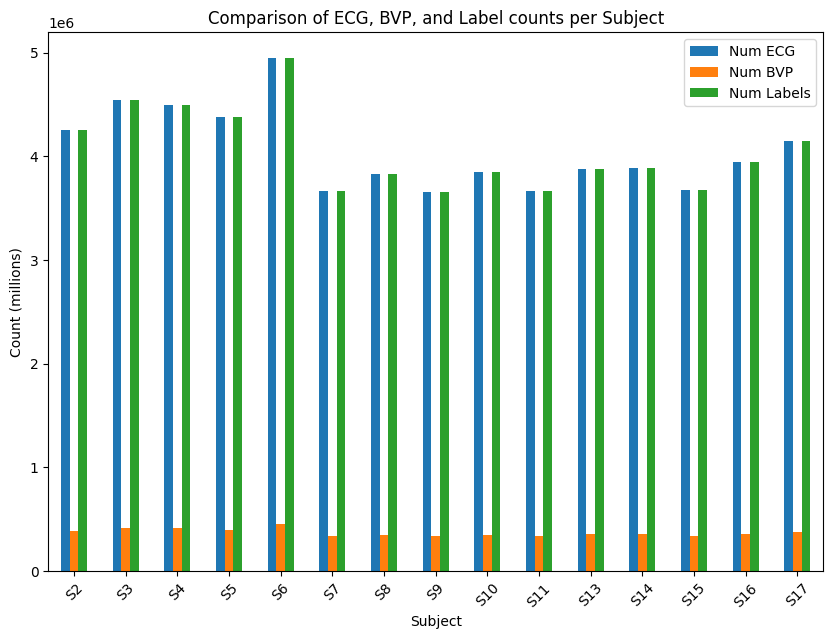

In [6]:
df_signal_lengths = []
for sub, data in SUBJECTS_DATA.items():
    df_signal_lengths.append({
        'Subject' : sub,
        'Num ECG' : len(data['signal']['chest']['ECG']),
        'Num BVP' : len(data['signal']['wrist']['BVP']),
        'Num Labels' : len(data['label'])
    })

df_signal_lengths = pd.DataFrame(df_signal_lengths)
df_signal_lengths = df_signal_lengths.set_index('Subject')

df_signal_lengths[['Num ECG', 'Num BVP', 'Num Labels']].plot(kind = 'bar', figsize = (10, 7))
plt.title('Comparison of ECG, BVP, and Label counts per Subject')
plt.xlabel('Subject')
plt.ylabel('Count (millions)')
plt.xticks(rotation = 45)
plt.legend()
plt.show()

Разликата во бројот на отчитувања од двата сензори е голема. Ова се должи на тоа што сензорот кај градите има рата од `700 Hz`, а сензорот на раката има рата од `64 Hz`.
> Ова ни кажува дека потребно е да се направи `resampling` на сигналите од едениот сензор со цел да има еднаков број податоци за секоја лабела.
> Друга опција е да се користат само податоците од сензорот кај градите при работа со моделите.

Бројот на лабели е еднаков со бројот на отчитувања од сензорот кај градите.
> Ова ни кажува дека лабелите биле поставени со иста фреквенција како овој сензор. Поради големата разлика во бројот на отчитувања кај двата сензори, најлесно е да се користат само ECG сигналите добиени од сензорот на градите.

Бројот на лабели се разликува меѓу учесниците. Причината за ова е разликата во времетраењето на сесиите кај секој од учесниците.
> Потребно е да потврдиме дека времетраењето на сесиите не е многу различно во споредба со другите учесници, за да се осигураме дека нема да има `bias` во податоците.

---

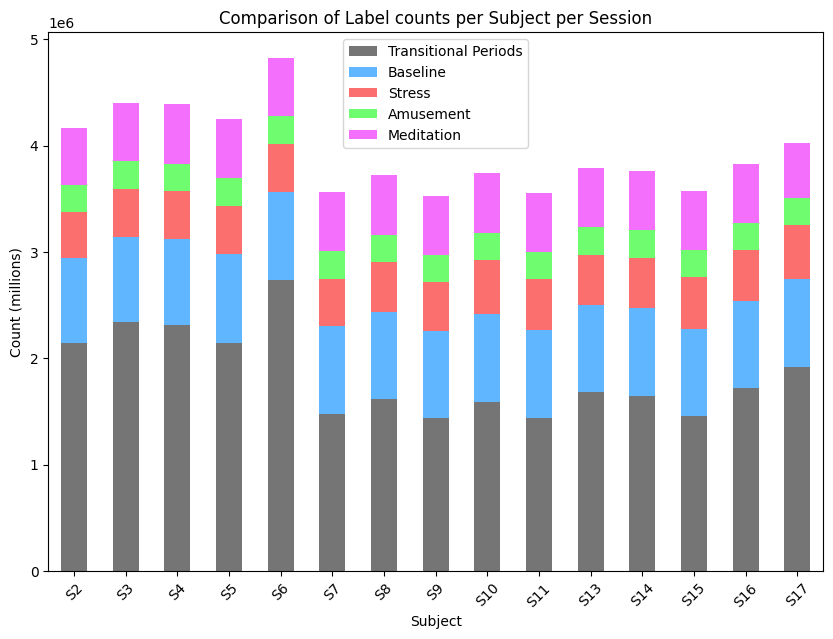

In [7]:
df_session_lengths = []
for sub, data in SUBJECTS_DATA.items():
    df_session_lengths.append({
        'Subject' : sub,
        'Transitional Periods' : list(data['label']).count(0),
        'Baseline' : list(data['label']).count(1),
        'Stress' : list(data['label']).count(2),
        'Amusement' : list(data['label']).count(3),
        'Meditation' : list(data['label']).count(4)
    })

df_session_lengths = pd.DataFrame(df_session_lengths)
df_session_lengths = df_session_lengths.set_index('Subject')

df_session_lengths[['Transitional Periods', 'Baseline', 'Stress', 'Amusement', 'Meditation']].plot(
    kind = 'bar', stacked = True, figsize = (10, 7),
    color = ['#757575', '#60b7ff', '#fc6f6f', '#6ffc6f', '#f36ffc']
)
plt.title('Comparison of Label counts per Subject per Session')
plt.xlabel('Subject')
plt.ylabel('Count (millions)')
plt.xticks(rotation = 45)
plt.legend()
plt.show()

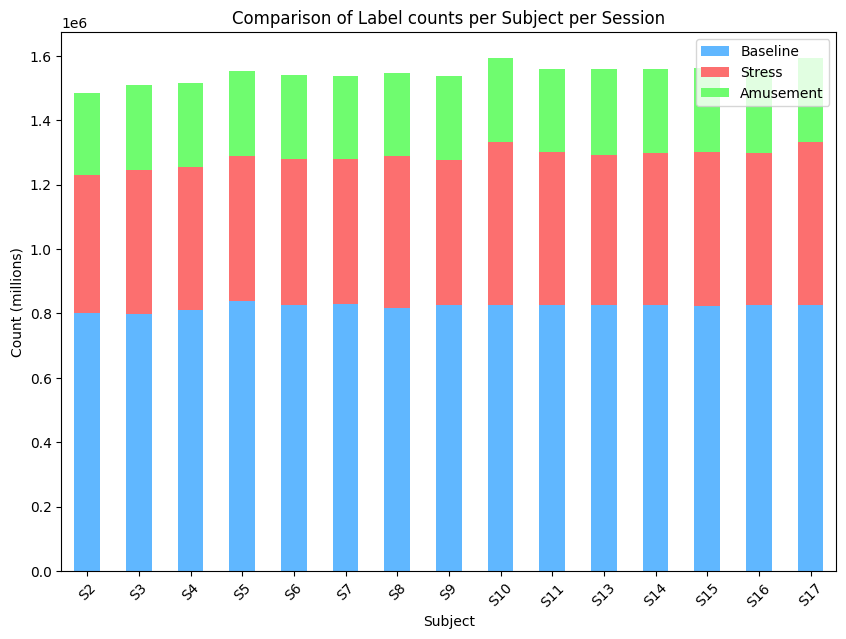

In [8]:
df_session_lengths[['Baseline', 'Stress', 'Amusement']].plot(
    kind = 'bar', stacked = True, figsize = (10, 7),
    color = ['#60b7ff', '#fc6f6f', '#6ffc6f']
)
plt.title('Comparison of Label counts per Subject per Session')
plt.xlabel('Subject')
plt.ylabel('Count (millions)')
plt.xticks(rotation = 45)
plt.legend()
plt.show()

Постои `imbalance` во лабелите за секоја од сесиите кои се од интерес (`Baseline`, `Stress`, `Amusement`). Ова претставува проблем затоа што моделот ќе има `bias` кон лабелата која доминира (`Baseline`) и дополнително `accuracy score` не е добра мерка за моделите затоа што половина и повеќе од лабелите се исти.
> За да се справиме со ова потребно е да искористиме `class_weight = 'balanced'` или слично во моделот за истиот да добива поголеми казни за грешно класифицирање на поретките лабели. Дополнително може да користиме `precision score` и `F1 score` како мерки за евалуација.

---

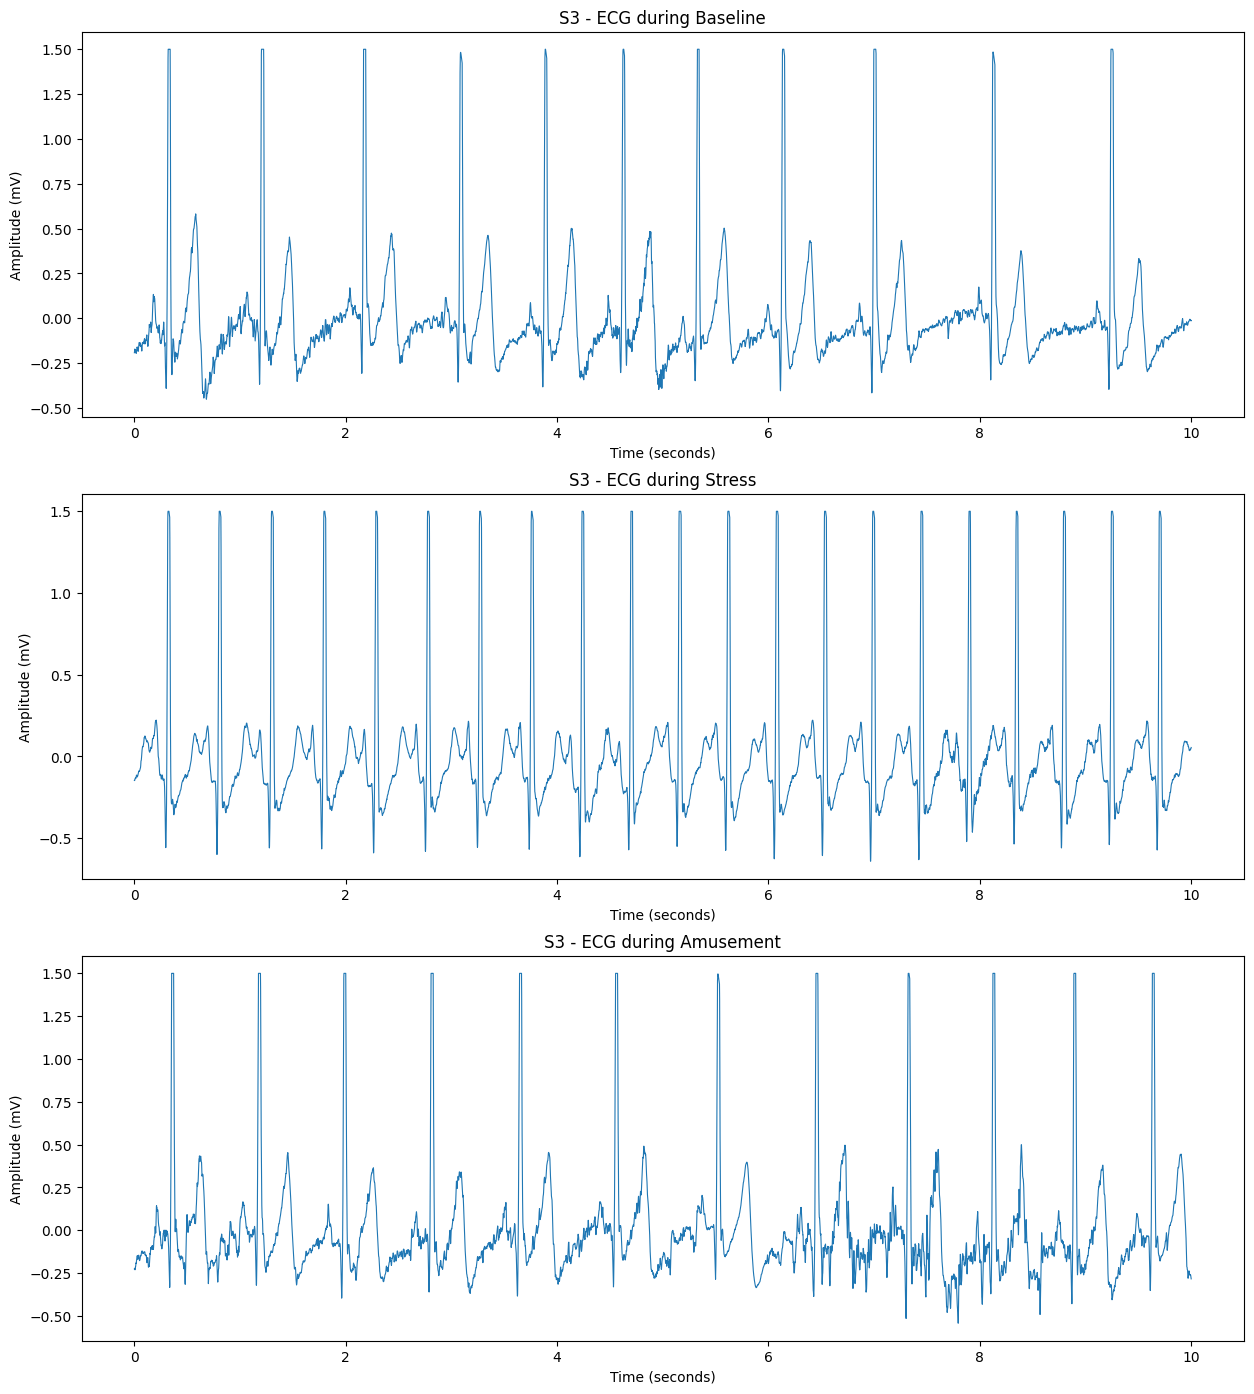

In [9]:
_, axes = plt.subplots(3, 1, figsize = (15, 17), sharex = False)

sub = 'S3'
signal = SUBJECTS_DATA[sub]['signal']['chest']['ECG'].flatten()
labels = SUBJECTS_DATA[sub]['label']

for axis, (label_id, label_name) in zip(axes, [(1, 'Baseline'), (2, 'Stress'), (3, 'Amusement')]):
    start_i = np.where(labels == label_id)[0][0]
    segment = signal[start_i : start_i + 10 * ECG_FS]  # 10 seconds segment

    axis.plot(np.linspace(0, 10, len(segment)), segment, linewidth = 0.8)
    axis.set_title(f'{sub} - ECG during {label_name}')
    axis.set_xlabel('Time (seconds)')
    axis.set_ylabel('Amplitude (mV)')
    
plt.show()

Може да се види дека сигналите се доволно чисти за детектирање на `peaks`. Дополнително може да забележиме разлика во сигналите во зависност од сесијата:
1. `Baseline` покажува поголеми празнини меѓу пиковите што сугестира нормален срцев ритам.
2. `Stress` покажува помали празнини меѓу пиковите со малку шум што сугестира забрзан срцев ритам.
3. `Amusement` покажува сигнал кој може да се интерпретира како нешто помеѓу `Baseline` и `Stress`.
> Ова е добар знак дека податоците ќе се значајни за моделот.

---

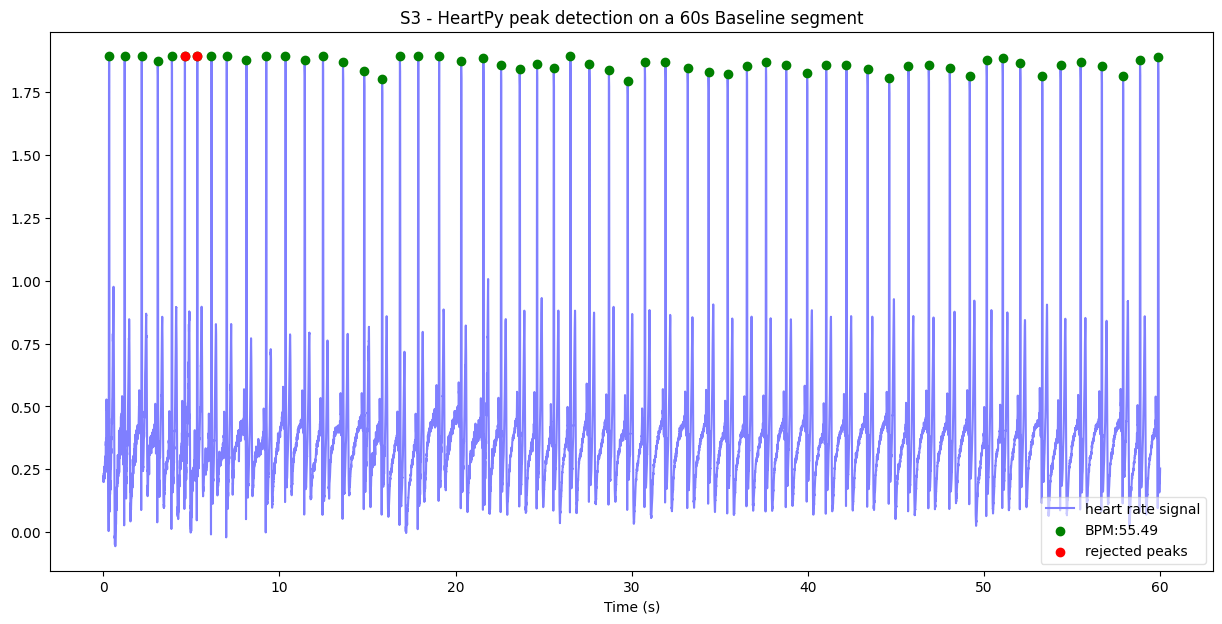

Extracted features:
* bpm             : 55.4877
* ibi             : 1081.3208
* sdnn            : 109.5300
* sdsd            : 69.5719
* rmssd           : 109.2037
* pnn20           : 0.8235
* pnn50           : 0.6667
* hr_mad          : 84.2857
* sd1             : 77.2086
* sd2             : 124.5649
* s               : 30214.2142
* sd1/sd2         : 0.6198
* breathingrate   : 0.1667


In [10]:
sub = 'S3'
signal = SUBJECTS_DATA[sub]['signal']['chest']['ECG'].flatten()
labels = SUBJECTS_DATA[sub]['label']

start_i = np.where(labels == 1)[0][0]
segment = signal[start_i : start_i + 60 * ECG_FS]  # 60 seconds Baseline segment

wd, m = hp.process(segment, sample_rate = ECG_FS)

hp.plotter(wd, m, figsize = (15, 7))
plt.title(f'{sub} - HeartPy peak detection on a 60s Baseline segment')
plt.show()

print('Extracted features:')
for key, val in m.items():
    print(f'* {key:<15} : {val:.4f}')

HeartPy успешно ги процесира сигналите и ги дава горенаведените податоци.
> Црвените точки не се проблем ако се во мал број како што е тука. Исто така нема `NaN` вредности во добиените податоци.

Податоци кои потенцијално можат да се искористат при класификација:
1. `bpm`: Може да служи како индикатор за релаксација и стрес/активност (`beats per minute`).
2. `ibi`: Време меѓу секое отчукување (`inter-beat interval`).
3. `sdnn`: Колку варира времето помеѓу секое нормално отчукување (`standard deviation of NN intervals`).
4. `rnssd`: Колку ратата на отчукување се менува помеѓу последователни отчукувања (`root mean square of successive differences`).
5. `pnn50`: Колку често последователни отчукувања се разликуваат за повеќе од 50ms (`% of successive intervals differing by 50ms or more`).
6. `hr_mad`: Колку ратата на отчукување варира од медијаната (`heart rate median absolute deviation`).
7. `sd1/sd2`: Може да служи за дополнителни информации околу состојбата (`ratio of short-term to long-term variability`).
8. `breathingrate`: Рата на дишење.

---

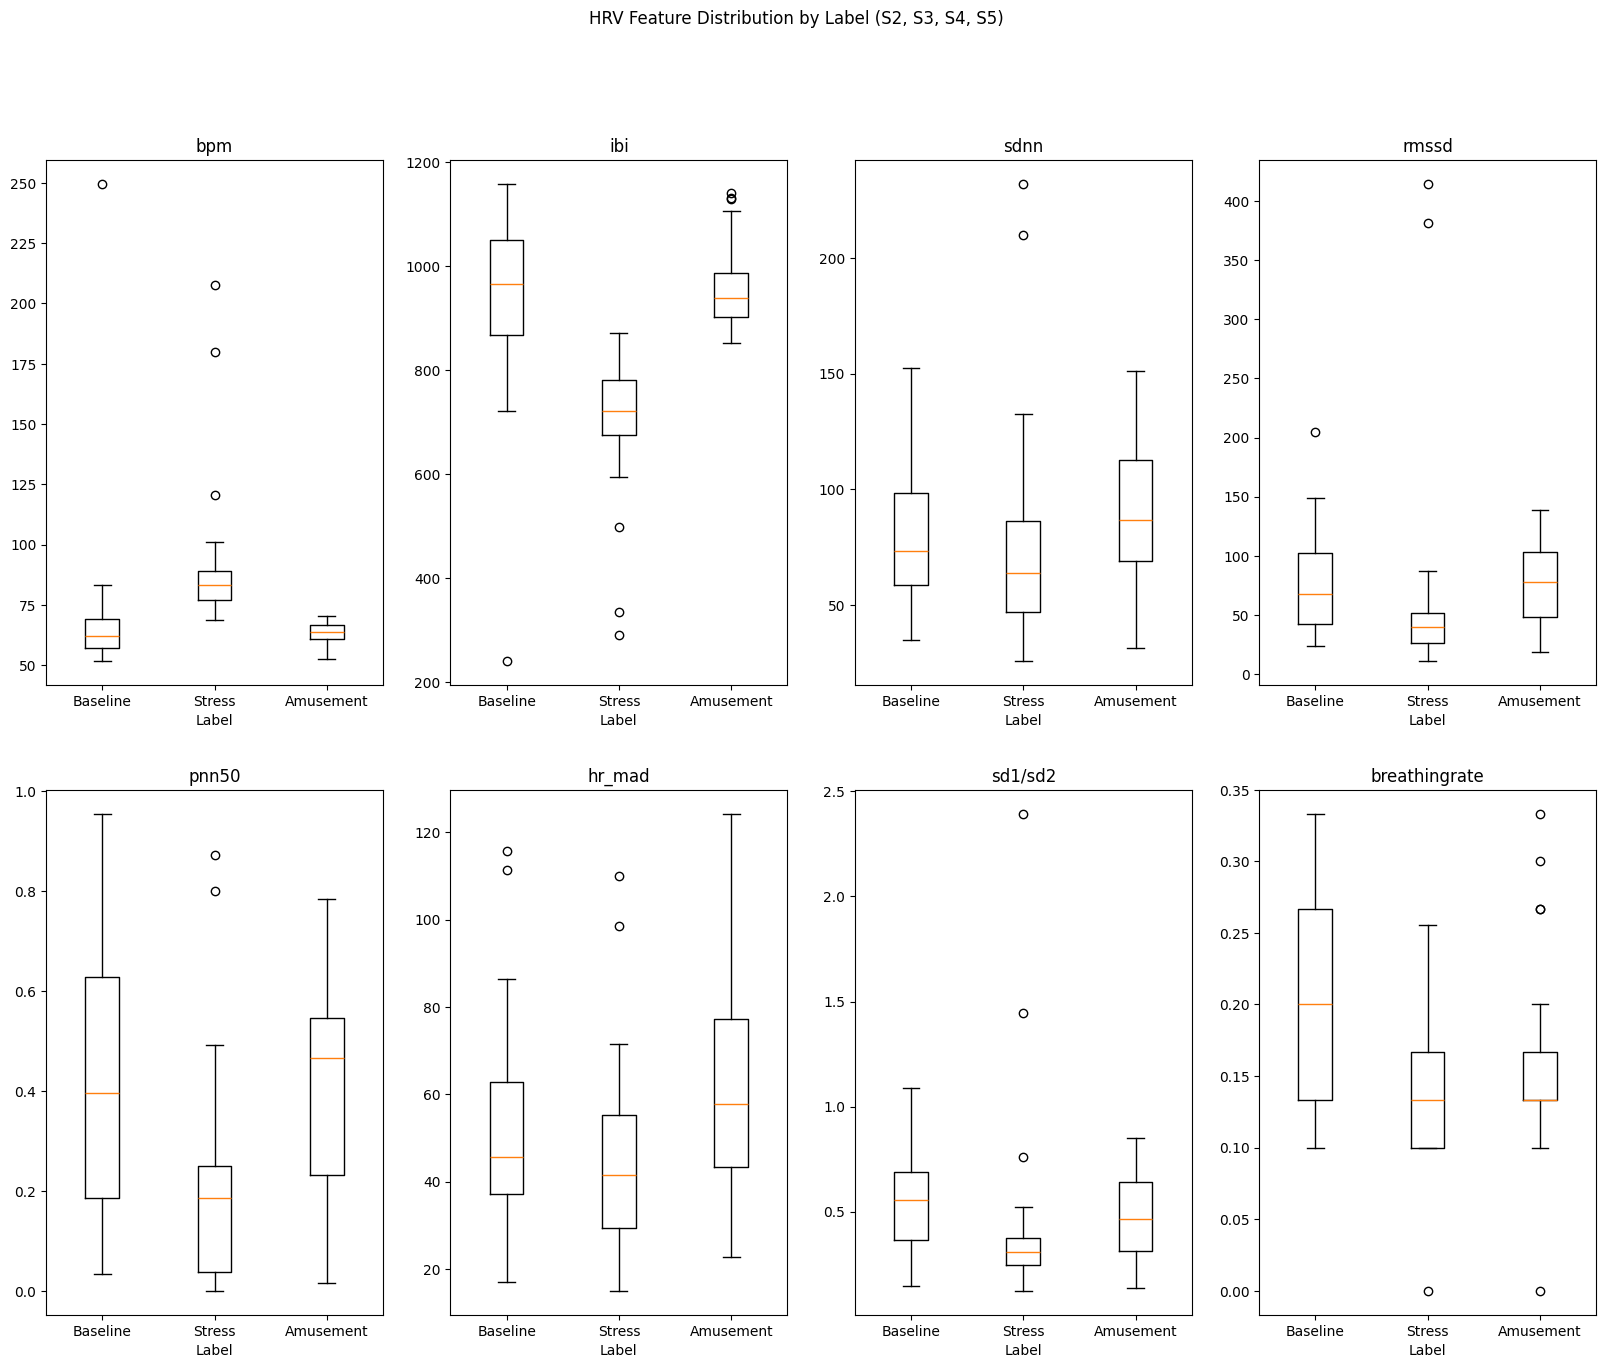

In [11]:
feature_names = ['bpm', 'ibi', 'sdnn', 'rmssd', 'pnn50', 'hr_mad', 'sd1/sd2', 'breathingrate']
label_mapping = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
window_length = 60 * ECG_FS  # 60 second segments


def extract_hrv_features(signal, fs):
    wd, m = hp.process(signal, sample_rate = fs)
    return [m[feat] for feat in feature_names]


records = []
for sub, data in SUBJECTS_DATA.items():
    if sub == 'S6':  # Take only a subset of subjects
        break
    
    signal = data['signal']['chest']['ECG'].flatten()
    labels = data['label']

    for start_i in range(0, len(signal) - window_length, window_length):  # Non-overlapping segments
        win_labels = labels[start_i : start_i + window_length]
        top_labels = np.bincount(win_labels[win_labels != 0]).argmax() if np.any(win_labels != 0) else 0
        if top_labels not in label_mapping:
            continue

        feats = extract_hrv_features(signal[start_i : start_i + window_length], ECG_FS)
        if feats:
            records.append([label_mapping[top_labels]] + feats)

df_feats = pd.DataFrame(records, columns = ['Label'] + feature_names)

_, axes = plt.subplots(2, 4, figsize = (20, 15))
for axis, feat in zip(axes.flatten(), feature_names):
    groups = [df_feats[df_feats['Label'] == i][feat] for i in label_mapping.values()]
    axis.boxplot(groups, labels = label_mapping.values())
    axis.set_title(feat)
    axis.set_xlabel('Label')

plt.suptitle('HRV Feature Distribution by Label (S2, S3, S4, S5)')
plt.show()

Ова може да се искористи за да одредиме кои податоци се значајни за моделот. Главно бараме податоци каде очигледно нивната распределба меѓу трите сесии нема преклопување. Може да се забележат и `outliers` кои најверојатно се појавуваат како резултат од синхронизацијата на сензорите.
> Според ова може да одредиме дека најзначајни податоци за моделот се оние каде нема преклопување на вредностите меѓу различните состојби, односно следните: `bpm`, `ibi`, и `rmssd`. Потоа `pnn50` и `sd1/sd2` имаат мало преклопување, па овие податоци сепак може да служат кога се придружени од останатите. Мерките `sdnn`, `hr_mad`, и `breathingrate` имаат позначајни преклопувања, па најверојатно не би биле многу корисни.

---

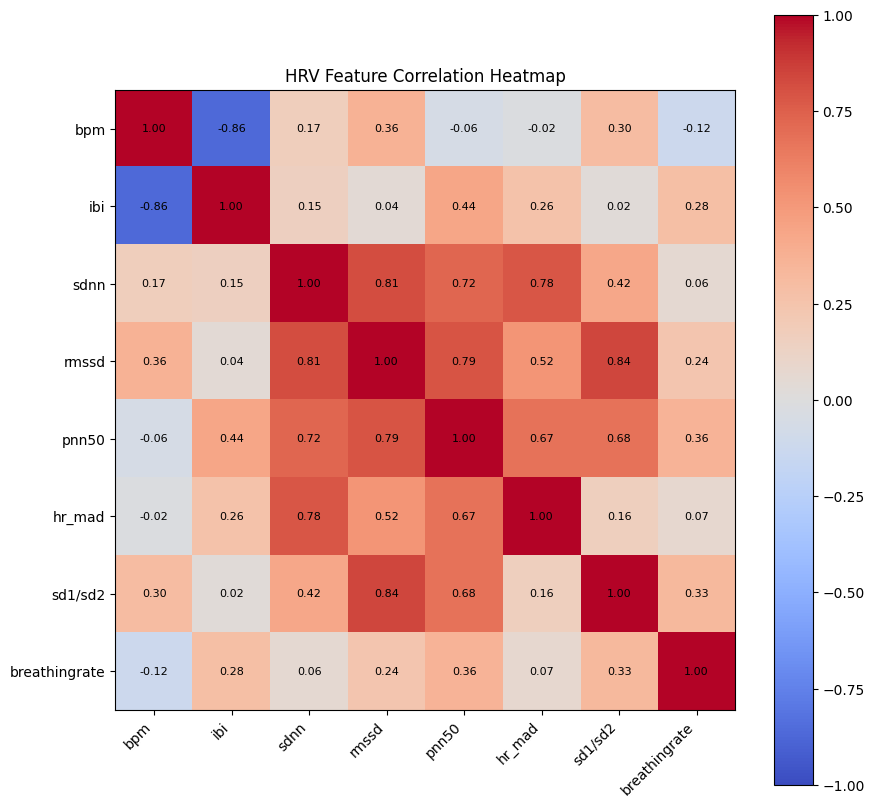

In [12]:
_, ax = plt.subplots(figsize = (10, 10))

correlation = df_feats[feature_names].corr()
im = ax.imshow(correlation, cmap = 'coolwarm', vmin = -1, vmax = 1)

plt.colorbar(im, ax = ax)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation = 45, ha = 'right')
ax.set_yticklabels(feature_names)

for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{correlation.iloc[i, j]:.2f}', ha = 'center', va = 'center', fontsize = 8)

plt.title('HRV Feature Correlation Heatmap')
plt.show()

Проверка за редундантни податоци.
> Очекувано, `bpm` и `ibi` имаат голема корелација. Голема корелација имаат и `sdnn`, `rmssd`, `pnn50`, и `hr_mad` што исто така е очекувано бидејќи сите даваат информации за варијациите во ратата на отчукување.

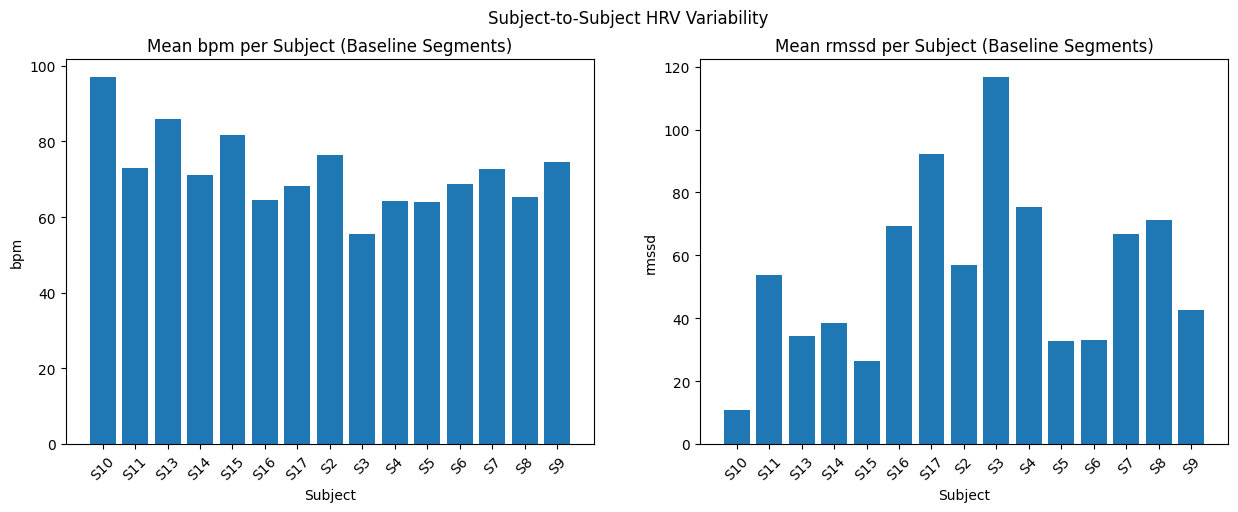

In [13]:
records = []
for sub, data in SUBJECTS_DATA.items():
    signal = data['signal']['chest']['ECG'].flatten()
    labels = data['label']

    windows = 0
    start_b = np.where(labels == 1)[0]
    for start_i in start_b[::window_length]:
        if windows >= 3:
            break

        segment = signal[start_i : start_i + window_length]
        if len(segment) < window_length:
            continue

        feats = extract_hrv_features(segment, ECG_FS)
        records.append({'Subject' : sub, 'bpm' : feats[0], 'rmssd' : feats[3]})
        windows += 1

df_vars = pd.DataFrame(records)
df_mean = df_vars.groupby('Subject').mean()

_, axes = plt.subplots(1, 2, figsize = (15, 5))
for axis, feat in zip(axes, ['bpm', 'rmssd']):
    axis.bar(df_mean.index, df_mean[feat])
    axis.set_title(f'Mean {feat} per Subject (Baseline Segments)')
    axis.set_xlabel('Subject')
    axis.set_ylabel(feat)
    axis.tick_params(axis = 'x', rotation = 45)

plt.suptitle('Subject-to-Subject HRV Variability')
plt.show()

Може да видиме дека варијабилноста е голема - `S10` има `~97 bpm` и `~15 rmssd`, додека `S3` има `~55 bpm` и `~117 rmssd`. Ова значи дека ако тренираме модел користејќи ги податоците од сите учесници без некаква нормализација, истиот би ја учел индивидуалната физиолошка состојба наместо одликите на стресот.
> За да се справиме со овој проблем, може да користиме `per-fold StandardScaler` за нормализирање на вредностите и `LOSO (Leave One Subject Out) cross-validation` за евалуација.

**LOSO:** Правење на `train-test split` по случајност или според одредена личност нема да даде точна евалуација на моделот бидејќи може да се случи податоците за човек од `test` множеството исто така да се појават и во `train` множеството, па моделот само ќе учи индивидуални карактеристики наместо одлики на стресни состојби.
> `LOSO` работи така што `train` множеството се состои од податоците за сите учесници освен еден, а `test` множеството се состои од податоците на тој еден учесник. Моделот се тренира повеќе пати на различни `test` податоци и финалниот резултат се зема како просек од сите тренирања.

**Per-fold StandardScaler**: Ова само значи дека скалерот се рекреира при секое ново тренирање за да ги гледа само податоците од `train` множеството.

---

# 
# Building Dataset

In [14]:
WINDOW_SAMPLES = 60 * ECG_FS  # 60 seconds
STEP_SAMPLES = 5 * ECG_FS    # 5 second step

LABEL_NAMES = {1 : 'Baseline', 2 : 'Stress', 3 : 'Amusement', 4 : 'Meditation'}
LABEL_TO_SESSION = {1 : 0, 2 : 1, 3 : 3, 4 : 2}

records = []
for sub, data in SUBJECTS_DATA.items():
    print(f'[-] Processing {sub}...', end = '\r')

    ecg = data['signal']['chest']['ECG'].flatten()
    temp = data['signal']['chest']['Temp'].flatten()
    resp = data['signal']['chest']['Resp'].flatten()
    labels = data['label']

    age = data['info']['Age']
    is_female = int(data['info']['Gender'] == 'female')
    quest = data['questionnaire']

    for start in range(0, len(ecg) - WINDOW_SAMPLES, STEP_SAMPLES):
        end = start + WINDOW_SAMPLES

        # Remove windows that transition from one state to another
        unique = set(labels[start:end])
        if len(unique) != 1 or 0 in unique:
            continue
            
        label = next(iter(unique))
        if label not in LABEL_NAMES:
            continue

        # HRV features from ECG
        hrv = extract_hrv_features(ecg[start:end], ECG_FS)
        if hrv is None:
            continue

        # Temp and Resp: mean over the window
        temp_mean = float(np.mean(temp[start:end]))
        resp_mean = float(np.mean(resp[start:end]))

        # Questionnaire answers for this session
        sess = LABEL_TO_SESSION[label]
        panas = sum(quest['PANAS'][sess]) if sess < len(quest['PANAS']) else None
        stai = sum(quest['STAI'][sess]) if sess < len(quest['STAI']) else None
        dim = quest['DIM'][sess] if sess < len(quest['DIM']) else [None, None]
        sssq = quest['SSSQ'][sess] if sess < len(quest['SSSQ']) else None

        record = {
            'subject' : sub,
            'label' : LABEL_NAMES[label],
            'age' : age,
            'is_female' : is_female,
            **dict(zip(feature_names, hrv)),
            'temp_mean' : temp_mean,
            'resp_mean' : resp_mean,
            'quest_panas' : panas,
            'quest_stai' : stai,
            'quest_dim_valence' : dim[0],
            'quest_dim_arousal' : dim[1],
            'quest_sssq' : sssq,
        }
        
        records.append(record)

    print(f'[✔] Processing {sub}...')

df = pd.DataFrame(records)
print(f'\nDataset shape: {df.shape}')
print(f'\nLabel distribution:\n{df["label"].value_counts()}\n')
df.head()

[✔] Processing S2...
[✔] Processing S3...
[✔] Processing S4...
[✔] Processing S5...
[✔] Processing S6...
[✔] Processing S7...
[✔] Processing S8...
[✔] Processing S9...
[✔] Processing S10...
[✔] Processing S11...
[✔] Processing S13...
[✔] Processing S14...
[✔] Processing S15...
[✔] Processing S16...
[✔] Processing S17...

Dataset shape: (8091, 19)

Label distribution:
label
Baseline      3342
Meditation    2001
Stress        1814
Amusement      934
Name: count, dtype: int64



,subject,label,age,is_female,bpm,ibi,sdnn,rmssd,pnn50,hr_mad,sd1/sd2,breathingrate,temp_mean,resp_mean,quest_panas,quest_stai,quest_dim_valence,quest_dim_arousal,quest_sssq
0,S2,Baseline,27,0,82.389963,728.244048,83.710324,44.326357,0.235294,42.857143,0.291267,0.200000,29.147476,0.067119,48,15,7,2,5
1,S2,Baseline,27,0,80.258185,747.587302,87.562001,52.143183,0.300000,68.571429,0.326360,0.166667,29.130991,-0.017135,48,15,7,2,5
2,S2,Baseline,27,0,76.154529,787.871720,96.479092,53.315981,0.322581,80.000000,0.293953,0.133333,29.110161,0.067110,48,15,7,2,5
3,S2,Baseline,27,0,76.000568,789.467787,93.739168,56.385608,0.375000,77.142857,0.320434,0.133333,29.088720,0.010486,48,15,7,2,5
4,S2,Baseline,27,0,75.564032,794.028571,88.184727,55.334481,0.400000,71.428571,0.321733,0.100000,29.064768,0.047531,48,15,7,2,5


In [15]:
df.isnull().sum()

subject              0
label                0
age                  0
is_female            0
bpm                  0
ibi                  0
sdnn                 0
rmssd                0
pnn50                0
hr_mad               0
sd1/sd2              0
breathingrate        0
temp_mean            0
resp_mean            0
quest_panas          0
quest_stai           0
quest_dim_valence    0
quest_dim_arousal    0
quest_sssq           0
dtype: int64

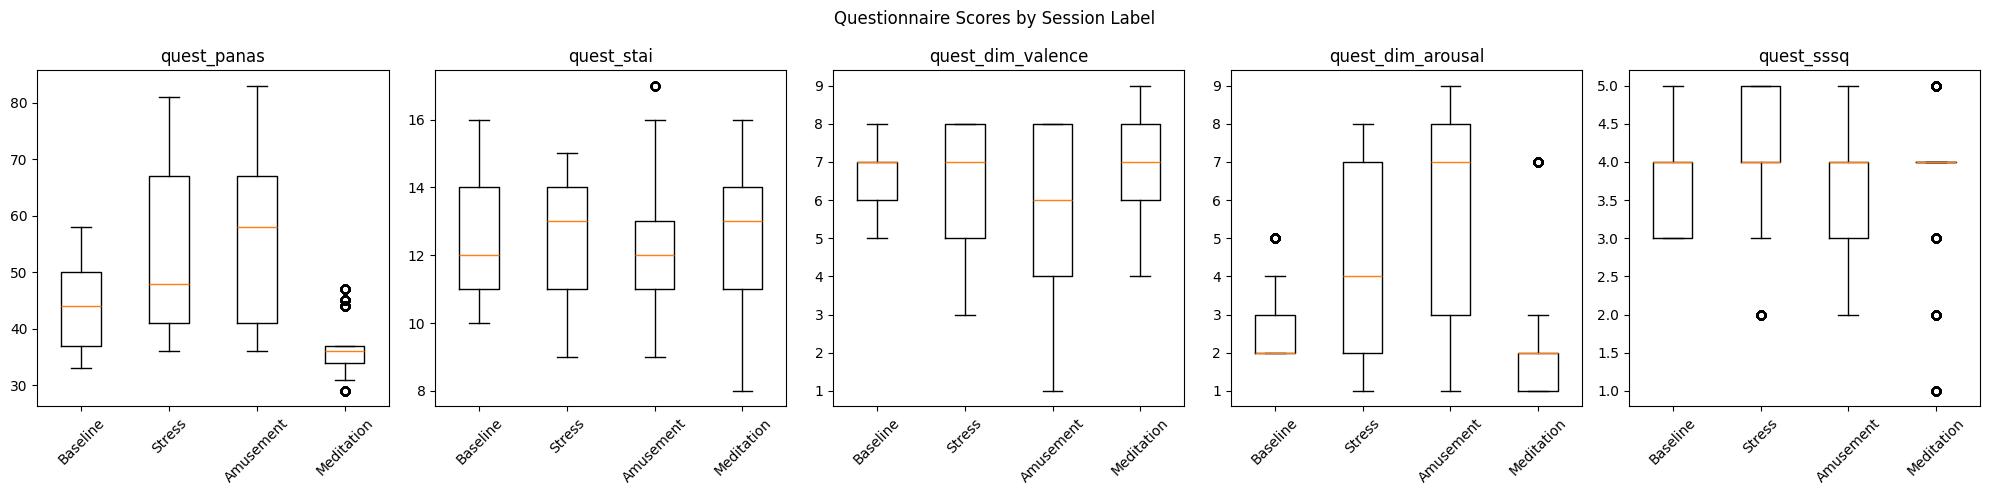

In [16]:
q_cols = ['quest_panas', 'quest_stai', 'quest_dim_valence', 'quest_dim_arousal', 'quest_sssq']
labels_order = ['Baseline', 'Stress', 'Amusement', 'Meditation']

_, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, q_cols):
    groups = [df[df['label'] == l][col].dropna() for l in labels_order]
    ax.boxplot(groups, labels=labels_order)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Questionnaire Scores by Session Label')
plt.tight_layout()
plt.show()

# 
# Models 1: Binary Classification w/o Questionnaire Data

In [17]:
FEATURE_COLS = [c for c in df.columns if c not in ['subject', 'label', 'target'] and not c.startswith('quest_')]
SUBJECTS = df['subject'].unique()

# Binary target: Stress=1, everything else=0
df['target'] = (df['label'] == 'Stress').astype(int)

def print_results(name, y_true, y_pred):
    print(f'\n{"="*50}\n {name}\n{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Non-stress', 'Stress']))

In [18]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM' : SVC(kernel='rbf', class_weight='balanced', random_state=42),
}

for name, clf in models.items():
    all_true, all_pred = [], []

    for test_sub in SUBJECTS:
        X_train = df[df['subject'] != test_sub][FEATURE_COLS].values
        y_train = df[df['subject'] != test_sub]['target'].values
        X_test = df[df['subject'] == test_sub][FEATURE_COLS].values
        y_test = df[df['subject'] == test_sub]['target'].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)
        all_true.extend(y_test)
        all_pred.extend(clf.predict(X_test))

    print_results(name, np.array(all_true), np.array(all_pred))


 Random Forest
              precision    recall  f1-score   support

  Non-stress       0.89      0.91      0.90      6277
      Stress       0.66      0.61      0.63      1814

    accuracy                           0.84      8091
   macro avg       0.77      0.76      0.77      8091
weighted avg       0.84      0.84      0.84      8091


 SVM
              precision    recall  f1-score   support

  Non-stress       0.92      0.87      0.89      6277
      Stress       0.62      0.75      0.68      1814

    accuracy                           0.84      8091
   macro avg       0.77      0.81      0.79      8091
weighted avg       0.85      0.84      0.85      8091



In [19]:
SEQ_LEN = 10
N_FEATURES = len(FEATURE_COLS)

class StressLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(N_FEATURES, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(h[-1]))

def make_sequences(X, y, seq_len):
    Xs = np.array([X[i : i + seq_len] for i in range(len(X) - seq_len + 1)])
    ys = y[seq_len - 1:]
    return Xs, ys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_true, all_pred = [], []

for test_sub in SUBJECTS:
    print(f'  Fold: test={test_sub}', end='\r')
    test_mask = df['subject'] == test_sub

    scaler = StandardScaler()
    scaler.fit(df[~test_mask][FEATURE_COLS].values)

    # Build sequences per subject to avoid cross-subject boundaries
    X_seqs, y_seqs = [], []
    for sub in SUBJECTS[SUBJECTS != test_sub]:
        mask = df['subject'] == sub
        X_sub = scaler.transform(df[mask][FEATURE_COLS].values)
        y_sub = df[mask]['target'].values
        Xs, ys = make_sequences(X_sub, y_sub, SEQ_LEN)
        X_seqs.append(Xs)
        y_seqs.append(ys)

    X_train = np.vstack(X_seqs).astype(np.float32)
    y_train = np.concatenate(y_seqs).astype(np.float32)
    X_test, y_test = make_sequences(
        scaler.transform(df[test_mask][FEATURE_COLS].values).astype(np.float32),
        df[test_mask]['target'].values.astype(np.float32),
        SEQ_LEN
    )

    # Class weight for imbalance
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True
    )

    model = StressLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model.train()
    for epoch in range(10):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test).to(device)
        preds = (torch.sigmoid(model(X_t).squeeze()) > 0.5).cpu().numpy().astype(int)

    all_true.extend(y_test.astype(int))
    all_pred.extend(preds)

print_results('LSTM', np.array(all_true), np.array(all_pred))

  Fold: test=S17
 LSTM
              precision    recall  f1-score   support

  Non-stress       0.91      0.85      0.88      6142
      Stress       0.58      0.71      0.64      1814

    accuracy                           0.82      7956
   macro avg       0.74      0.78      0.76      7956
weighted avg       0.83      0.82      0.82      7956



# 
# Models 2: Binary Classification w/ Questionnaire Data

In [20]:
FEATURE_COLS = [c for c in df.columns if c not in ['subject', 'label', 'target']]
SUBJECTS = df['subject'].unique()

# Binary target: Stress=1, everything else=0
df['target'] = (df['label'] == 'Stress').astype(int)

def print_results(name, y_true, y_pred):
    print(f'\n{"="*50}\n {name}\n{"="*50}')
    print(classification_report(y_true, y_pred, target_names=['Non-stress', 'Stress']))

In [21]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM' : SVC(kernel='rbf', class_weight='balanced', random_state=42),
}

for name, clf in models.items():
    all_true, all_pred = [], []

    for test_sub in SUBJECTS:
        X_train = df[df['subject'] != test_sub][FEATURE_COLS].values
        y_train = df[df['subject'] != test_sub]['target'].values
        X_test = df[df['subject'] == test_sub][FEATURE_COLS].values
        y_test = df[df['subject'] == test_sub]['target'].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)
        all_true.extend(y_test)
        all_pred.extend(clf.predict(X_test))

    print_results(name, np.array(all_true), np.array(all_pred))


 Random Forest
              precision    recall  f1-score   support

  Non-stress       0.87      0.93      0.90      6277
      Stress       0.69      0.52      0.60      1814

    accuracy                           0.84      8091
   macro avg       0.78      0.73      0.75      8091
weighted avg       0.83      0.84      0.83      8091


 SVM
              precision    recall  f1-score   support

  Non-stress       0.88      0.91      0.90      6277
      Stress       0.65      0.58      0.61      1814

    accuracy                           0.84      8091
   macro avg       0.77      0.74      0.76      8091
weighted avg       0.83      0.84      0.83      8091



In [22]:
SEQ_LEN = 10
N_FEATURES = len(FEATURE_COLS)

class StressLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(N_FEATURES, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(h[-1]))

def make_sequences(X, y, seq_len):
    Xs = np.array([X[i : i + seq_len] for i in range(len(X) - seq_len + 1)])
    ys = y[seq_len - 1:]
    return Xs, ys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_true, all_pred = [], []

for test_sub in SUBJECTS:
    print(f'  Fold: test={test_sub}', end='\r')
    test_mask = df['subject'] == test_sub

    scaler = StandardScaler()
    scaler.fit(df[~test_mask][FEATURE_COLS].values)

    # Build sequences per subject to avoid cross-subject boundaries
    X_seqs, y_seqs = [], []
    for sub in SUBJECTS[SUBJECTS != test_sub]:
        mask  = df['subject'] == sub
        X_sub = scaler.transform(df[mask][FEATURE_COLS].values)
        y_sub = df[mask]['target'].values
        Xs, ys = make_sequences(X_sub, y_sub, SEQ_LEN)
        X_seqs.append(Xs)
        y_seqs.append(ys)

    X_train = np.vstack(X_seqs).astype(np.float32)
    y_train = np.concatenate(y_seqs).astype(np.float32)
    X_test, y_test = make_sequences(
        scaler.transform(df[test_mask][FEATURE_COLS].values).astype(np.float32),
        df[test_mask]['target'].values.astype(np.float32),
        SEQ_LEN
    )

    # Class weight for imbalance
    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True
    )

    model = StressLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model.train()
    for epoch in range(10):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test).to(device)
        preds = (torch.sigmoid(model(X_t).squeeze()) > 0.5).cpu().numpy().astype(int)

    all_true.extend(y_test.astype(int))
    all_pred.extend(preds)

print_results('LSTM', np.array(all_true), np.array(all_pred))

  Fold: test=S17
 LSTM
              precision    recall  f1-score   support

  Non-stress       0.91      0.92      0.92      6142
      Stress       0.72      0.70      0.71      1814

    accuracy                           0.87      7956
   macro avg       0.82      0.81      0.81      7956
weighted avg       0.87      0.87      0.87      7956



# 
# Model 3: Multi-class Classification w/o Questionnaire Data

In [23]:
FEATURE_COLS = [c for c in df.columns if c not in ['subject', 'label', 'target'] and not c.startswith('quest_')]
CLASS_NAMES = ['Rest', 'Stress', 'Amusement']
SUBJECTS = df['subject'].unique()

# Rest=0 (Baseline + Meditation), Stress=1, Amusement=2
df['target'] = df['label'].map({'Baseline': 0, 'Meditation': 0, 'Stress': 1, 'Amusement': 2})

def print_results(name, y_true, y_pred):
    print(f'\n{"="*50}\n {name}\n{"="*50}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [24]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM' : SVC(kernel='rbf', class_weight='balanced', random_state=42),
}

for name, clf in models.items():
    all_true, all_pred = [], []

    for test_sub in SUBJECTS:
        X_train = df[df['subject'] != test_sub][FEATURE_COLS].values
        y_train = df[df['subject'] != test_sub]['target'].values
        X_test = df[df['subject'] == test_sub][FEATURE_COLS].values
        y_test = df[df['subject'] == test_sub]['target'].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)
        all_true.extend(y_test)
        all_pred.extend(clf.predict(X_test))

    print_results(name, np.array(all_true), np.array(all_pred))


 Random Forest
              precision    recall  f1-score   support

        Rest       0.78      0.86      0.82      5343
      Stress       0.66      0.66      0.66      1814
   Amusement       0.27      0.11      0.15       934

    accuracy                           0.73      8091
   macro avg       0.57      0.54      0.54      8091
weighted avg       0.69      0.73      0.71      8091


 SVM
              precision    recall  f1-score   support

        Rest       0.79      0.62      0.70      5343
      Stress       0.63      0.74      0.68      1814
   Amusement       0.18      0.34      0.24       934

    accuracy                           0.62      8091
   macro avg       0.53      0.57      0.54      8091
weighted avg       0.68      0.62      0.64      8091



In [25]:
SEQ_LEN = 10
N_FEATURES = len(FEATURE_COLS)
N_CLASSES = 3

class StressLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(N_FEATURES, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, N_CLASSES)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(h[-1]))

def make_sequences(X, y, seq_len):
    Xs = np.array([X[i : i + seq_len] for i in range(len(X) - seq_len + 1)])
    ys = y[seq_len - 1:]
    return Xs, ys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_true, all_pred = [], []

for test_sub in SUBJECTS:
    print(f'  Fold: test={test_sub}', end='\r')
    test_mask = df['subject'] == test_sub

    scaler = StandardScaler()
    scaler.fit(df[~test_mask][FEATURE_COLS].values)

    X_seqs, y_seqs = [], []
    for sub in SUBJECTS[SUBJECTS != test_sub]:
        mask = df['subject'] == sub
        X_sub = scaler.transform(df[mask][FEATURE_COLS].values)
        y_sub = df[mask]['target'].values
        Xs, ys = make_sequences(X_sub, y_sub, SEQ_LEN)
        X_seqs.append(Xs)
        y_seqs.append(ys)

    X_train = np.vstack(X_seqs).astype(np.float32)
    y_train = np.concatenate(y_seqs).astype(np.int64)
    X_test, y_test = make_sequences(
        scaler.transform(df[test_mask][FEATURE_COLS].values).astype(np.float32),
        df[test_mask]['target'].values.astype(np.int64),
        SEQ_LEN
    )

    # Class weights to handle imbalance across all 3 classes
    counts = np.bincount(y_train, minlength=N_CLASSES).astype(np.float32)
    class_weight = torch.tensor(counts.sum() / (N_CLASSES * counts)).to(device)

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True
    )

    model = StressLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(weight=class_weight)

    model.train()
    for epoch in range(10):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test).to(device)
        preds = model(X_t).argmax(dim=1).cpu().numpy()

    all_true.extend(y_test.astype(int))
    all_pred.extend(preds)

print_results('LSTM', np.array(all_true), np.array(all_pred))

  Fold: test=S17
 LSTM
              precision    recall  f1-score   support

        Rest       0.76      0.62      0.68      5208
      Stress       0.55      0.65      0.60      1814
   Amusement       0.19      0.33      0.24       934

    accuracy                           0.59      7956
   macro avg       0.50      0.53      0.51      7956
weighted avg       0.65      0.59      0.61      7956



# 
# Models 4: Multi-class Classification w/ Questionnaire Data

In [26]:
FEATURE_COLS = [c for c in df.columns if c not in ['subject', 'label', 'target']]
CLASS_NAMES = ['Rest', 'Stress', 'Amusement']
SUBJECTS = df['subject'].unique()

# Rest=0 (Baseline + Meditation), Stress=1, Amusement=2
df['target'] = df['label'].map({'Baseline': 0, 'Meditation': 0, 'Stress': 1, 'Amusement': 2})

def print_results(name, y_true, y_pred):
    print(f'\n{"="*50}\n {name}\n{"="*50}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [27]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM' : SVC(kernel='rbf', class_weight='balanced', random_state=42),
}

for name, clf in models.items():
    all_true, all_pred = [], []

    for test_sub in SUBJECTS:
        X_train = df[df['subject'] != test_sub][FEATURE_COLS].values
        y_train = df[df['subject'] != test_sub]['target'].values
        X_test = df[df['subject'] == test_sub][FEATURE_COLS].values
        y_test = df[df['subject'] == test_sub]['target'].values

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)
        all_true.extend(y_test)
        all_pred.extend(clf.predict(X_test))

    print_results(name, np.array(all_true), np.array(all_pred))


 Random Forest
              precision    recall  f1-score   support

        Rest       0.84      0.88      0.86      5343
      Stress       0.65      0.73      0.69      1814
   Amusement       0.76      0.40      0.52       934

    accuracy                           0.79      8091
   macro avg       0.75      0.67      0.69      8091
weighted avg       0.79      0.79      0.78      8091


 SVM
              precision    recall  f1-score   support

        Rest       0.84      0.80      0.82      5343
      Stress       0.62      0.58      0.60      1814
   Amusement       0.37      0.51      0.43       934

    accuracy                           0.72      8091
   macro avg       0.61      0.63      0.62      8091
weighted avg       0.73      0.72      0.72      8091



In [28]:
SEQ_LEN = 10
N_FEATURES = len(FEATURE_COLS)
N_CLASSES = 3

class StressLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(N_FEATURES, 64, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, N_CLASSES)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(self.dropout(h[-1]))

def make_sequences(X, y, seq_len):
    Xs = np.array([X[i : i + seq_len] for i in range(len(X) - seq_len + 1)])
    ys = y[seq_len - 1:]
    return Xs, ys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
all_true, all_pred = [], []

for test_sub in SUBJECTS:
    print(f'  Fold: test={test_sub}', end='\r')
    test_mask = df['subject'] == test_sub

    scaler = StandardScaler()
    scaler.fit(df[~test_mask][FEATURE_COLS].values)

    X_seqs, y_seqs = [], []
    for sub in SUBJECTS[SUBJECTS != test_sub]:
        mask = df['subject'] == sub
        X_sub = scaler.transform(df[mask][FEATURE_COLS].values)
        y_sub = df[mask]['target'].values
        Xs, ys = make_sequences(X_sub, y_sub, SEQ_LEN)
        X_seqs.append(Xs)
        y_seqs.append(ys)

    X_train = np.vstack(X_seqs).astype(np.float32)
    y_train = np.concatenate(y_seqs).astype(np.int64)
    X_test, y_test = make_sequences(
        scaler.transform(df[test_mask][FEATURE_COLS].values).astype(np.float32),
        df[test_mask]['target'].values.astype(np.int64),
        SEQ_LEN
    )

    # Class weights to handle imbalance across all 3 classes
    counts = np.bincount(y_train, minlength=N_CLASSES).astype(np.float32)
    class_weight = torch.tensor(counts.sum() / (N_CLASSES * counts)).to(device)

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
        batch_size=64, shuffle=True
    )

    model = StressLSTM().to(device)
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.CrossEntropyLoss(weight=class_weight)

    model.train()
    for epoch in range(10):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test).to(device)
        preds = model(X_t).argmax(dim=1).cpu().numpy()

    all_true.extend(y_test.astype(int))
    all_pred.extend(preds)

print_results('LSTM', np.array(all_true), np.array(all_pred))

  Fold: test=S17
 LSTM
              precision    recall  f1-score   support

        Rest       0.87      0.70      0.78      5208
      Stress       0.62      0.67      0.64      1814
   Amusement       0.31      0.58      0.40       934

    accuracy                           0.68      7956
   macro avg       0.60      0.65      0.61      7956
weighted avg       0.74      0.68      0.70      7956

